In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape        # how many rows & columns
df.info()       # column types
df.describe()   # statistics (mean, min, max...)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
df.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

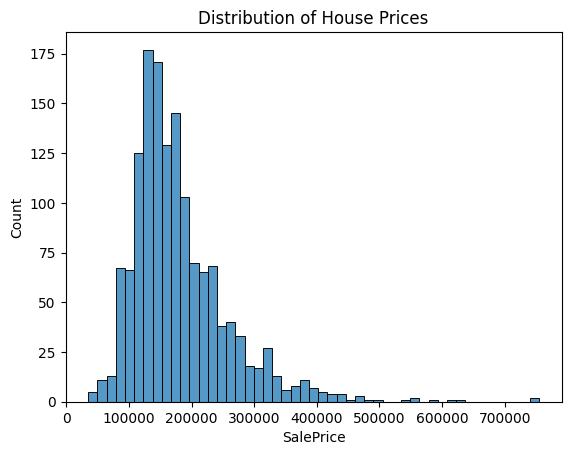

In [5]:

sns.histplot(df['SalePrice'])
plt.title("Distribution of House Prices")
plt.show()

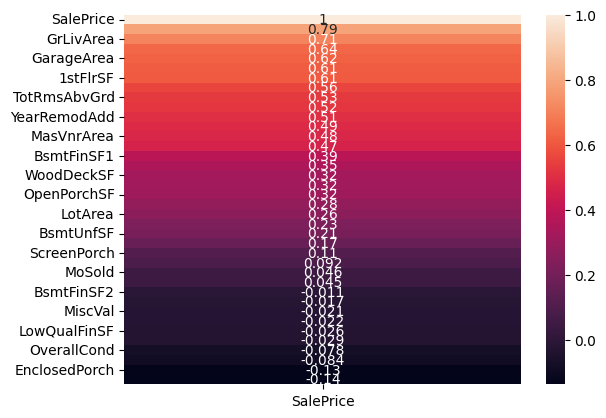

In [6]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr[['SalePrice']].sort_values('SalePrice', ascending=False), 
            annot=True)
plt.show()

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


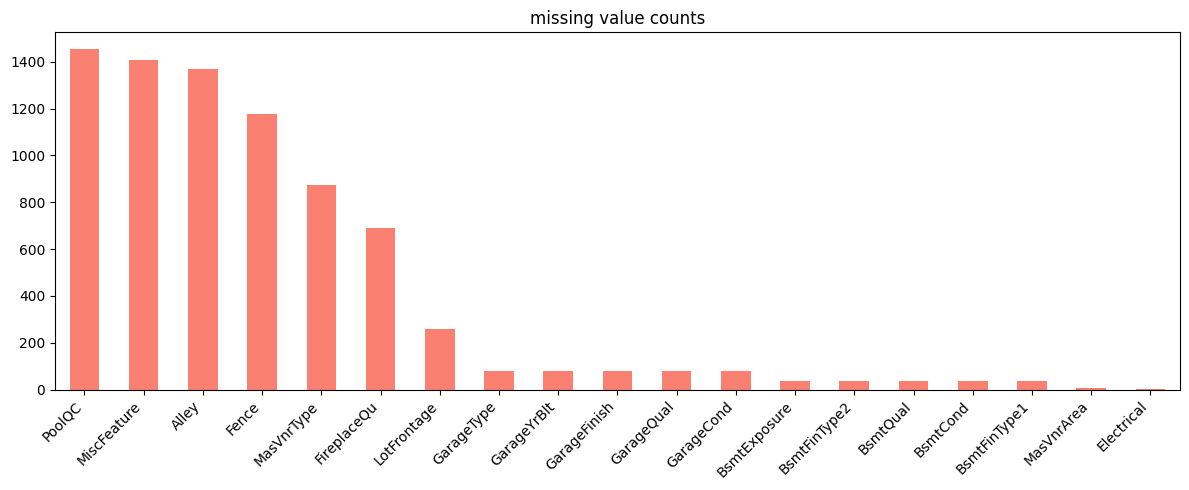

In [8]:
plt.figure(figsize=(12,5))
missing.plot(kind='bar', color='salmon')
plt.title('missing value counts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/missing_values.png')
plt.show()

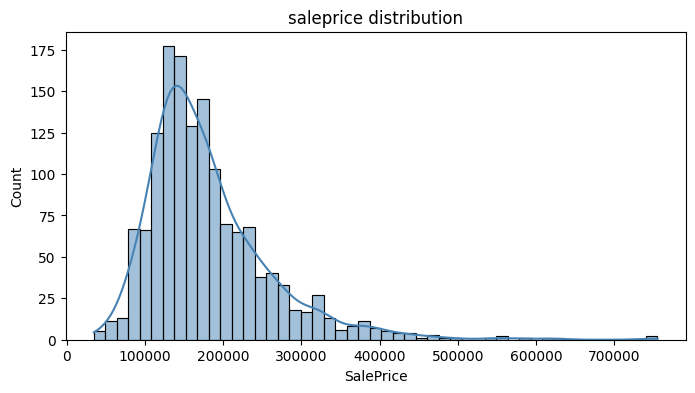

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.title('saleprice distribution')
plt.show()

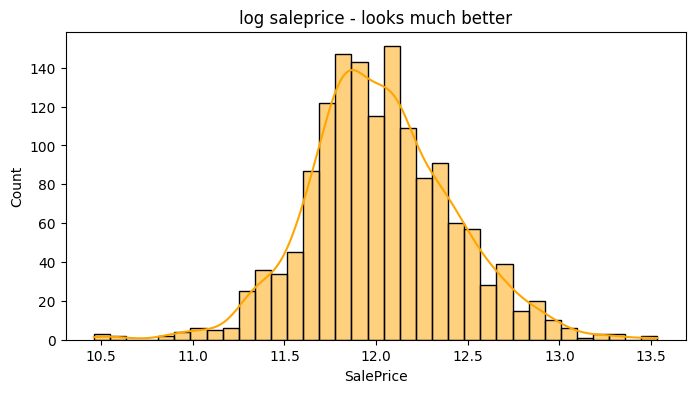

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df['SalePrice']), kde=True, color='orange')
plt.title('log saleprice - looks much better')
plt.savefig('../outputs/saleprice_dist.png')
plt.show()

In [11]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


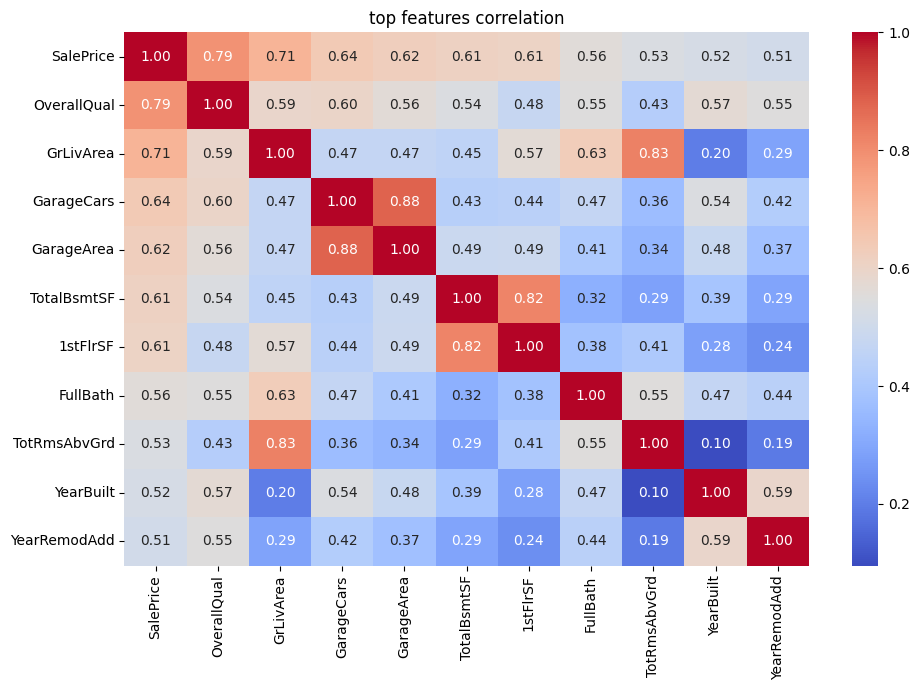

In [12]:
top_cols = corr.head(11).index

plt.figure(figsize=(10,7))
sns.heatmap(df[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('top features correlation')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png')
plt.show()

C:\Users\Janvi Prajapati\AppData\Local\Temp\ipykernel_15440\2489842997.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='Blues')


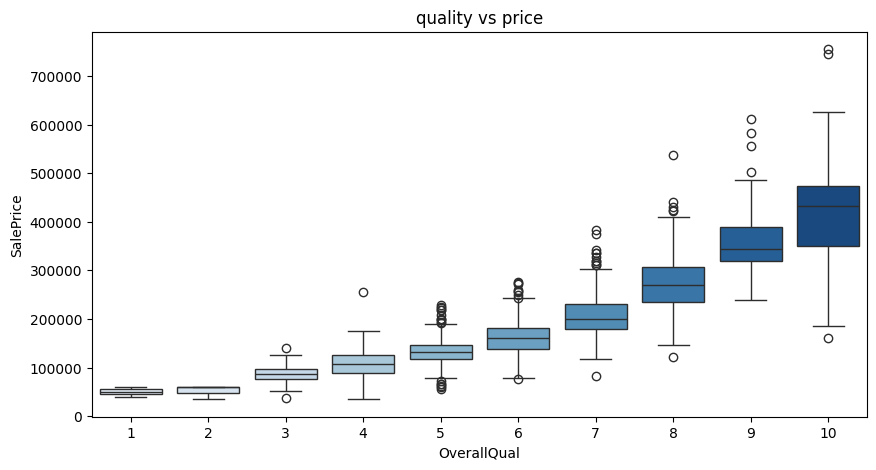

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='Blues')
plt.title('quality vs price')
plt.savefig('../outputs/quality_vs_price.png')
plt.show()

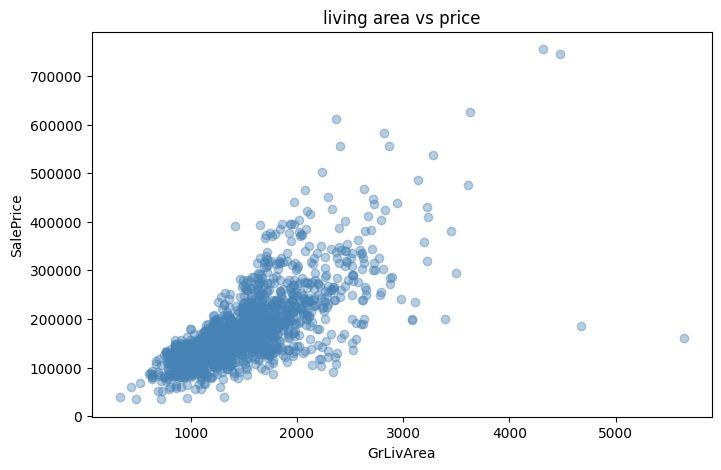

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='steelblue')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('living area vs price')
plt.savefig('../outputs/area_vs_price.png')
plt.show()

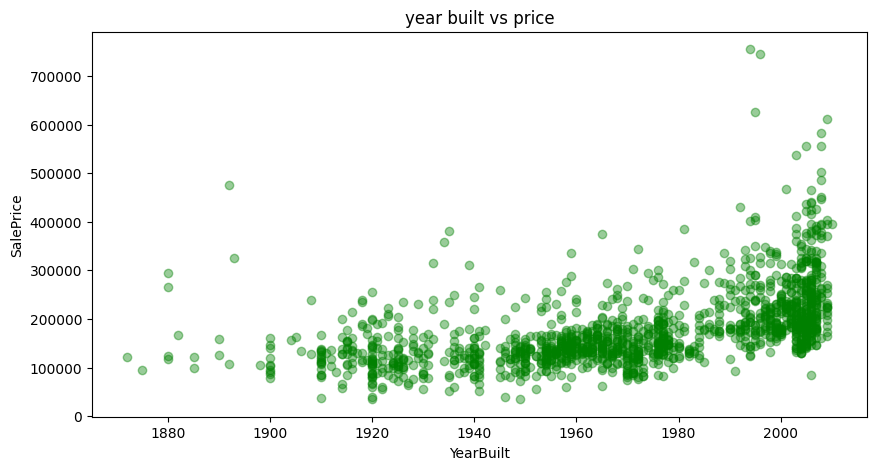

In [15]:
plt.figure(figsize=(10,5))
plt.scatter(df['YearBuilt'], df['SalePrice'], alpha=0.4, color='green')
plt.title('year built vs price')
plt.xlabel('YearBuilt')
plt.ylabel('SalePrice')
plt.show()

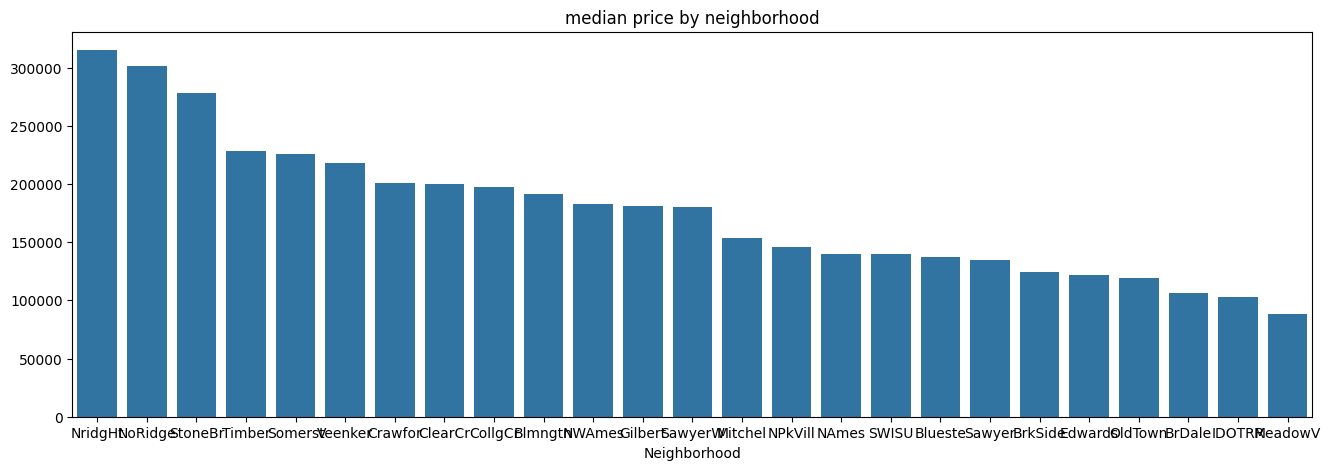

In [16]:
plt.figure(figsize=(16,5))
nb = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
sns.barplot(x=nb.index, y=nb.values)
plt.title('median price by neighborhood')

plt.savefig('../outputs/neighborhood_price.png')
plt.show()

In [17]:
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print(f"outlier rows: {outliers.index.tolist()}")

outlier rows: [523, 1298]


In [18]:
import importlib, sys
sys.path.append('../src')
import preprocess as pre
importlib.reload(pre)

X_train, X_test, y = pre.preprocess('../data/train.csv', '../data/test.csv')
print(X_train.shape)
print(X_train[['HouseAge', 'TotalSF', 'TotalBaths', 'QualityXArea']].head())

(1460, 84)
   HouseAge  TotalSF  TotalBaths  QualityXArea
0         5   2566.0         3.5         11970
1        31   2524.0         2.5          7572
2         7   2706.0         3.5         12502
3        91   2473.0         2.0         12019
4         8   3343.0         3.5         17584


In [21]:
import sys
sys.path.append('../src')

import importlib
import train as train_module
importlib.reload(train_module)

train_module.train()

loading & preprocessing data...
  train size : (1168, 84)
  val size   : (292, 84)

linear regression:
  MAE  : $17,957
  RMSE : $28,896
  R²   : 0.8839

random forest:
  MAE  : $17,158
  RMSE : $29,253
  R²   : 0.8873

xgboost:
  MAE  : $15,363
  RMSE : $26,127
  R²   : 0.8997

best model : XGBoost (lowest RMSE)
model saved to models/model.pkl


In [22]:
import sys
sys.path.append('../src')
import predict as predict_module
import importlib
importlib.reload(predict_module)

predict_module.predict()

loading model & data...
predictions saved to outputs/predictions.csv

sample predictions:
  Id  SalePrice
1461     120396
1462     158722
1463     184244
1464     189648
1465     194465
1466     176258
1467     180198
1468     171349
1469     178318
1470     121994

price range : $48,190 - $532,572
average price : $177,380
